Not running in Google Colab -- using the bundled example image: images/corrupted_image.png


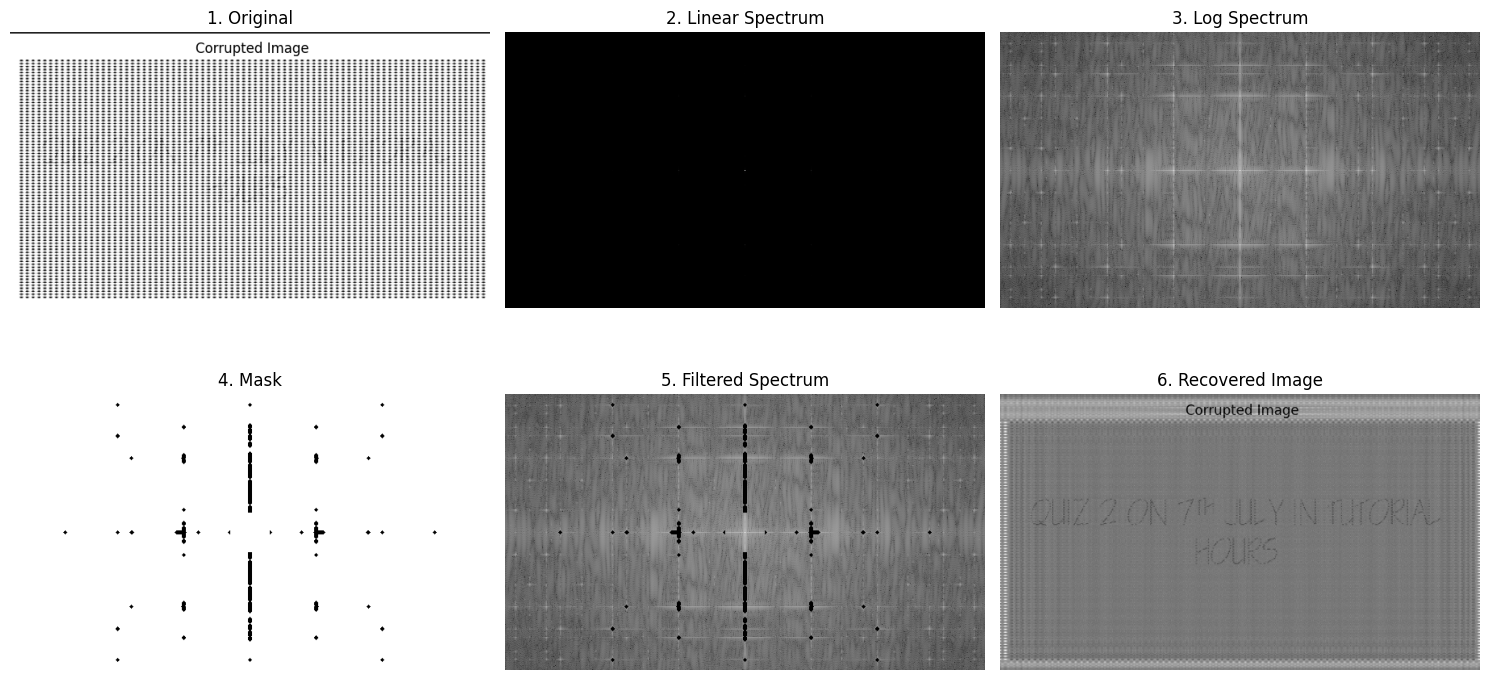

In [1]:
import os
import zipfile
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

# Works both in Google Colab (upload your own file) and locally/on GitHub,
# where it falls back to the bundled example image below.
DEFAULT_IMAGE = "images/corrupted_image.png"

try:
    from google.colab import files
    print("Upload your zip or image file:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    image_path = filename

    # if it's a zip file, extract it and find the image
    if zipfile.is_zipfile(filename):
        with zipfile.ZipFile(filename, 'r') as z:
            z.extractall("files")

        for root, dirs, files_list in os.walk("files"):
            for f in files_list:
                if "ghost" in f.lower() or f.lower().endswith(('.png', '.jpg')):
                    image_path = os.path.join(root, f)
                    break
except ImportError:
    print(f"Not running in Google Colab -- using the bundled example image: {DEFAULT_IMAGE}")
    image_path = DEFAULT_IMAGE

# read the image in grayscale (0)
img = cv2.imread(image_path, 0)

if img is None:
    raise FileNotFoundError(f"Could not load image at '{image_path}'")

# fourier transform stuff
fft_img = np.fft.fft2(img)
fft_shift = np.fft.fftshift(fft_img)

# get magnitude spectrums
mag_linear = np.abs(fft_shift)
mag_db = 20 * np.log10(mag_linear + 1)

# set up the filter mask
r, c = img.shape
mid_r, mid_c = r // 2, c // 2

mask = np.ones((r, c), np.uint8)

# calculate distance from center
y, x = np.ogrid[:r, :c]
dist = np.sqrt((y - mid_r)**2 + (x - mid_c)**2)

# find the really bright spots (noise spikes)
threshold = np.percentile(mag_db, 99.8)
spikes = mag_db > threshold

# Each noise spike leaks energy into a few neighboring frequency bins
# (spectral leakage), not just the single brightest pixel. Blocking only
# the exact peak pixel leaves a faint residual of the periodic pattern in
# the recovered image. Dilating the spike mask by a couple of pixels
# catches that leakage too, at the cost of masking <1.2% of the spectrum.
spikes = ndimage.binary_dilation(spikes, iterations=2)

# block the spikes, but keep the center safe (radius 25)
mask[spikes] = 0
mask[dist < 25] = 1

# apply mask to the shifted fft
filtered_shift = fft_shift * mask
filtered_mag_db = 20 * np.log10(np.abs(filtered_shift) + 1)

# reverse the fourier transform to get the image back
ifft_shift = np.fft.ifftshift(filtered_shift)
img_back = np.fft.ifft2(ifft_shift)
recovered_img = np.abs(img_back)

# plot the 6 images
plt.figure(figsize=(15, 8))

#1. Original Corrupted Image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('1. Original')
plt.axis('off')

# 2. Linear Magnitude Spectrum
plt.subplot(2, 3, 2)
plt.imshow(mag_linear, cmap='gray')
plt.title('2. Linear Spectrum')
plt.axis('off')

# 3. Logarithmic Magnitude Spectrum (dB)
plt.subplot(2, 3, 3)
plt.imshow(mag_db, cmap='gray')
plt.title('3. Log Spectrum')
plt.axis('off')

# 4. Filter Mask Used (Show where spikes were notched)
plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title('4. Mask')
plt.axis('off')

# 5. Cleaned Logarithmic Magnitude Spectrum
plt.subplot(2, 3, 5)
plt.imshow(filtered_mag_db, cmap='gray')
plt.title('5. Filtered Spectrum')
plt.axis('off')

# 6. Final Decoded Output Image
plt.subplot(2, 3, 6)
plt.imshow(recovered_img, cmap='gray')
plt.title('6. Recovered Image')
plt.axis('off')

plt.tight_layout()
plt.show()
